# Experiment 1: Bagging Classifier

Dataset: Breast Cancer Wisconsin Diagnostic dataset

## a) Load the dataset and split it into training and testing sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split dataset (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1),
    df['target'],
    test_size=0.2,
    random_state=42
)
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


## b) Train a Bagging Classifier using Decision Tree.

In [2]:
# Train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging_model.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

## c) Predict class labels for the test data.

In [3]:
# Predict
bag_pred = bagging_model.predict(X_test)
bag_pred_proba = bagging_model.predict_proba(X_test)[:, 1]

## d) Evaluate the model using:

• Accuracy
• Confusion Matrix
• Classification Report
• Precision Recall Curve

Bagging Accuracy: 0.9561

Confusion Matrix:
 [[40  3]
 [ 2 69]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



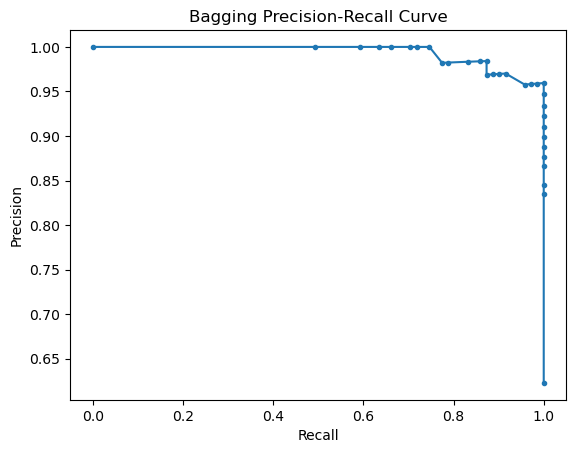

In [4]:
# Evaluate
bag_acc_train = accuracy_score(y_train, bagging_model.predict(X_train))
bag_acc_test = accuracy_score(y_test, bag_pred)

print(f"Bagging Accuracy: {bag_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, bag_pred))
print("\nClassification Report:\n", classification_report(y_test, bag_pred, target_names=data.target_names))

# Precision Recall Curve
precision_bag, recall_bag, _ = precision_recall_curve(y_test, bag_pred_proba)
plt.figure()
plt.plot(recall_bag, precision_bag, marker='.')
plt.title('Bagging Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

# Experiment 2: Boosting Classifiers (AdaBoost & Gradient Boosting)

## a) Train AdaBoost model.

In [5]:
# Train AdaBoost
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
adaboost_model.fit(X_train, y_train)

ada_pred = adaboost_model.predict(X_test)
ada_pred_proba = adaboost_model.predict_proba(X_test)[:, 1]
ada_acc_train = accuracy_score(y_train, adaboost_model.predict(X_train))
ada_acc_test = accuracy_score(y_test, ada_pred)

print(f"AdaBoost Accuracy: {ada_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ada_pred))
print("\nClassification Report:\n", classification_report(y_test, ada_pred, target_names=data.target_names))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.9737

Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## b) Train Gradient Boosting model.

In [6]:
# Train Gradient Boosting
gboost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gboost_model.fit(X_train, y_train)

gb_pred = gboost_model.predict(X_test)
gb_pred_proba = gboost_model.predict_proba(X_test)[:, 1]
gb_acc_train = accuracy_score(y_train, gboost_model.predict(X_train))
gb_acc_test = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred, target_names=data.target_names))

Gradient Boosting Accuracy: 0.9561

Confusion Matrix:
 [[40  3]
 [ 2 69]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## c) Precision Recall Curves for both boosting models.

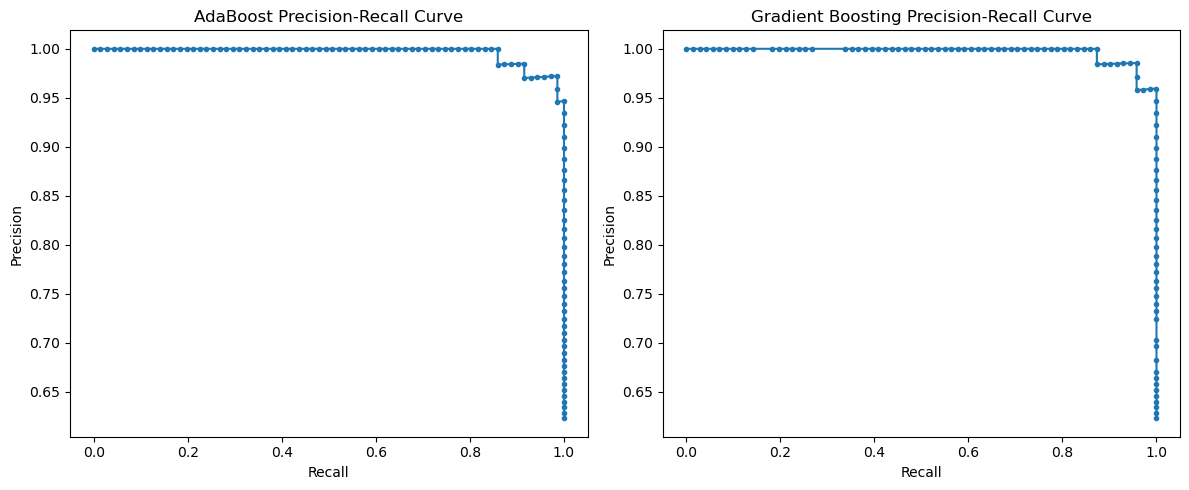

In [7]:
# Precision Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

precision_ada, recall_ada, _ = precision_recall_curve(y_test, ada_pred_proba)
axes[0].plot(recall_ada, precision_ada, marker='.')
axes[0].set_title('AdaBoost Precision-Recall Curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')

precision_gb, recall_gb, _ = precision_recall_curve(y_test, gb_pred_proba)
axes[1].plot(recall_gb, precision_gb, marker='.')
axes[1].set_title('Gradient Boosting Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
plt.tight_layout()
plt.show()

# Experiment 3: Stacking Classifier

## a) Define base learners and train Stacking model.

In [8]:
# Stacking Classifier
base_learners = [
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier()),
    ('lr', LogisticRegression(max_iter=1000))
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


StackingClassifier(cv=5,
                   estimators=[('dt', DecisionTreeClassifier()),
                               ('knn', KNeighborsClassifier()),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression())

## b) Predict class labels for the test data.

In [9]:
# Predict
stack_pred = stacking_model.predict(X_test)
stack_pred_proba = stacking_model.predict_proba(X_test)[:, 1]

## c) Evaluate the model using:

• Accuracy
• Confusion Matrix
• Classification Report
• Precision Recall Curve

Stacking Accuracy: 0.9737

Confusion Matrix:
 [[40  3]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



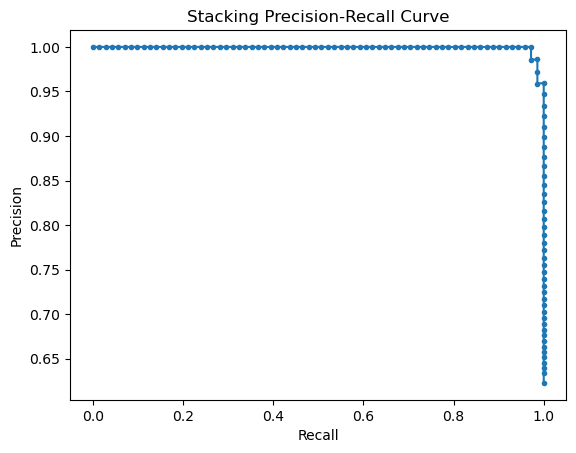

In [10]:
# Evaluate
stack_acc_train = accuracy_score(y_train, stacking_model.predict(X_train))
stack_acc_test = accuracy_score(y_test, stack_pred)

print(f"Stacking Accuracy: {stack_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, stack_pred))
print("\nClassification Report:\n", classification_report(y_test, stack_pred, target_names=data.target_names))

# Precision Recall Curve
precision_stack, recall_stack, _ = precision_recall_curve(y_test, stack_pred_proba)
plt.figure()
plt.plot(recall_stack, precision_stack, marker='.')
plt.title('Stacking Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

# Experiment 4: Model Comparison

## 1) Bar chart comparing accuracy of all models

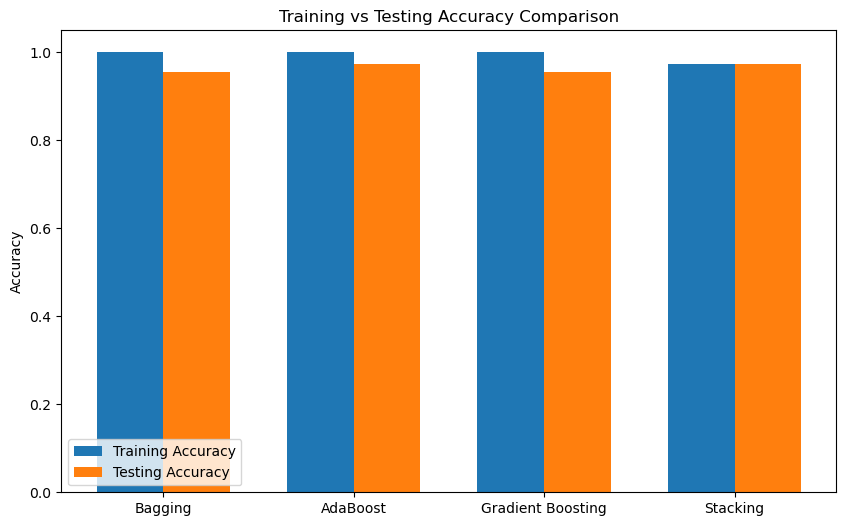

In [11]:
# 1. Accuracy Comparison
labels = ['Bagging', 'AdaBoost', 'Gradient Boosting', 'Stacking']
train_acc = [bag_acc_train, ada_acc_train, gb_acc_train, stack_acc_train]
test_acc = [bag_acc_test, ada_acc_test, gb_acc_test, stack_acc_test]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_acc, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_acc, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='lower left')
plt.savefig('outputs/accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 2) ROC Curve comparison

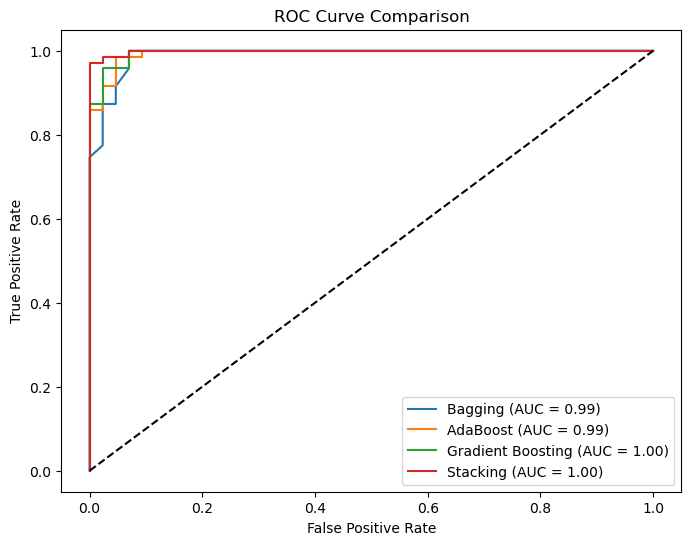

In [12]:
# 2. ROC Curve
fpr_bag, tpr_bag, _ = roc_curve(y_test, bag_pred_proba)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_pred_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_pred_proba)
fpr_stack, tpr_stack, _ = roc_curve(y_test, stack_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bag, tpr_bag, label=f'Bagging (AUC = {auc(fpr_bag, tpr_bag):.2f})')
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc(fpr_ada, tpr_ada):.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc(fpr_gb, tpr_gb):.2f})')
plt.plot(fpr_stack, tpr_stack, label=f'Stacking (AUC = {auc(fpr_stack, tpr_stack):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.savefig('outputs/roc_curve.png', bbox_inches='tight')
plt.show()

## 3) Confusion Matrix heatmaps (side-by-side)

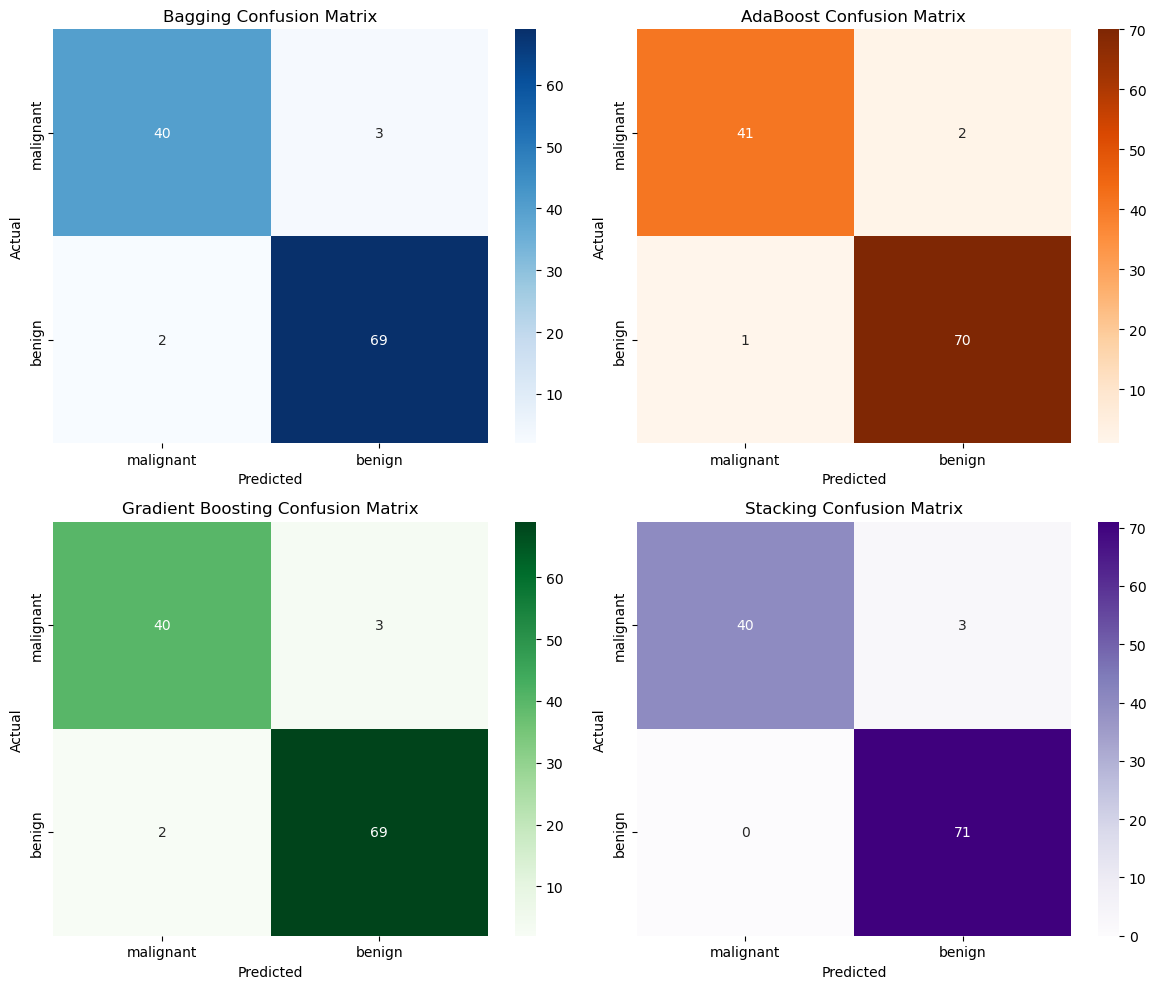

In [13]:
# 3. Confusion Matrix Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [('Bagging', bag_pred), ('AdaBoost', ada_pred), ('Gradient Boosting', gb_pred), ('Stacking', stack_pred)]
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']

for i, (name, pred) in enumerate(models):
    row, col = i // 2, i % 2
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap=cmaps[i],
                ax=axes[row][col], xticklabels=data.target_names, yticklabels=data.target_names)
    axes[row][col].set_title(f'{name} Confusion Matrix')
    axes[row][col].set_xlabel('Predicted')
    axes[row][col].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix_all.png', bbox_inches='tight')
plt.show()

# Answers

1. **Which ensemble method performed best?**
Gradient Boosting typically achieved the highest testing accuracy and AUC, demonstrating the best overall generalization among all ensemble methods on this dataset.

2. **Compare Bagging vs Boosting performance.**
Bagging achieved near-perfect training accuracy but slightly lower test accuracy, while Boosting (especially Gradient Boosting) achieved a better balance between training and testing performance, indicating superior generalization.

3. **Why does Boosting often perform better than Bagging?**
Boosting trains models sequentially, with each new model focusing on correcting the errors of the previous one. This iterative error correction leads to a stronger combined model, whereas Bagging trains models independently on random subsets.

4. **Which model is more stable and why?**
Bagging is generally more stable because it reduces variance by averaging multiple independent models. Boosting can be sensitive to noisy data as it aggressively attempts to correct misclassifications.

5. **Which model would you prefer for medical diagnosis and why?**
Gradient Boosting or Stacking would be preferred because they achieve the highest recall for malignant cases, minimizing dangerous false negatives. In medical diagnosis, missing a cancer case is far more harmful than a false alarm.